# LLM Serving & Inference: From Model to Production API

In the previous notebook, we studied alignment: how models are tuned to better follow human preferences using methods such as RLHF and DPO.

Now the model is trained. The model is aligned. The next production question is:

> How do we actually serve an LLM to thousands or millions of users?

**Serving** is the layer between a trained model and the people or applications that use it. It turns model weights into a reliable product interface: an API that accepts requests, generates tokens, streams partial outputs, handles concurrency, and protects the system from overload.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain the end-to-end LLM serving pipeline
- Distinguish offline, online, batch, and real-time inference
- Understand why token-by-token generation creates unique serving challenges
- Explain KV cache and why it matters for latency
- Compare traditional batching with continuous batching
- Simulate streaming responses and API-style serving
- Recognize common production problems and best practices


In [1]:
import json
import time
from dataclasses import dataclass
from typing import Dict, Iterable, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)


## Training Is Finished. Now What?

Training produces model weights. Alignment improves behavior. Neither one is enough to create a production system.

A serving system must answer practical questions:

- How does a user request reach the model?
- How are prompts converted into tokens?
- How are tokens generated and decoded?
- How do many users share limited GPU memory?
- How do we stream partial answers instead of waiting for the full response?
- How do we monitor latency, errors, and capacity?

Serving is where machine learning meets systems engineering.


## The Production Pipeline

A simplified online LLM serving pipeline looks like this:

```text
User -> API -> Tokenizer -> LLM -> Decoder -> Response
```

Each stage has a specific job. The API validates and routes the request. The tokenizer converts text into integer token IDs. The LLM predicts the next token repeatedly. The decoder converts token IDs back into text. The response layer returns JSON or streams chunks to the client.


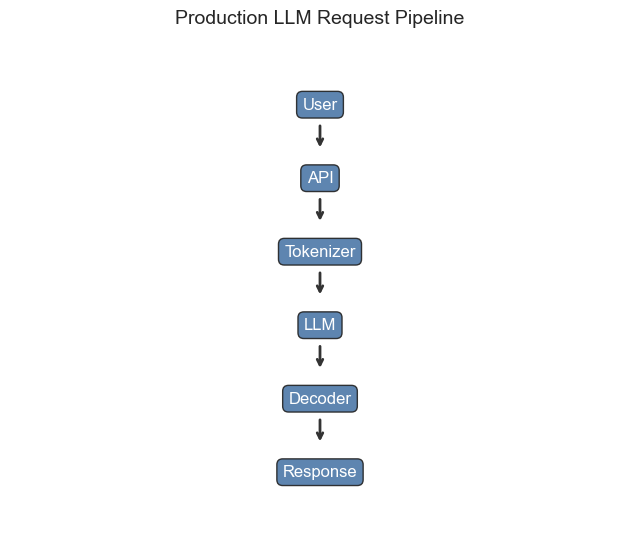

In [2]:
def draw_vertical_pipeline(steps, title, color="#4c78a8"):
    """Draw a vertical workflow diagram with arrows."""
    fig, ax = plt.subplots(figsize=(8, 0.8 * len(steps) + 1.5))
    y_positions = np.arange(len(steps))[::-1]

    for y, step in zip(y_positions, steps):
        ax.text(
            0.5,
            y,
            step,
            ha="center",
            va="center",
            fontsize=12,
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": color,
                "edgecolor": "#222222",
                "alpha": 0.9,
            },
            color="white",
        )

    for y in y_positions[:-1]:
        ax.annotate(
            "",
            xy=(0.5, y - 0.62),
            xytext=(0.5, y - 0.25),
            arrowprops={"arrowstyle": "->", "lw": 2, "color": "#333333"},
        )

    ax.set_title(title, fontsize=14, pad=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.8, len(steps) - 0.2)
    ax.axis("off")
    plt.show()


production_steps = ["User", "API", "Tokenizer", "LLM", "Decoder", "Response"]
draw_vertical_pipeline(production_steps, "Production LLM Request Pipeline")


In [3]:
pipeline_table = pd.DataFrame(
    [
        {
            "Stage": "User",
            "Responsibility": "Sends a prompt through an application, SDK, or HTTP client",
            "Engineering concern": "Input limits, authentication, user experience",
        },
        {
            "Stage": "API",
            "Responsibility": "Validates, authenticates, queues, and routes the request",
            "Engineering concern": "Rate limits, schemas, timeouts, safety checks",
        },
        {
            "Stage": "Tokenizer",
            "Responsibility": "Converts text into token IDs",
            "Engineering concern": "Token limits, prompt length, special tokens",
        },
        {
            "Stage": "LLM",
            "Responsibility": "Runs forward passes and predicts next-token probabilities",
            "Engineering concern": "GPU memory, batching, cache, kernels",
        },
        {
            "Stage": "Decoder",
            "Responsibility": "Selects tokens and converts IDs back to text",
            "Engineering concern": "Sampling, stop tokens, repetition control",
        },
        {
            "Stage": "Response",
            "Responsibility": "Returns JSON or streams chunks to the client",
            "Engineering concern": "Latency, partial output, errors, observability",
        },
    ]
)

pipeline_table


,Stage,Responsibility,Engineering concern
0,User,"Sends a prompt through an application, SDK, or...","Input limits, authentication, user experience"
1,API,"Validates, authenticates, queues, and routes t...","Rate limits, schemas, timeouts, safety checks"
2,Tokenizer,Converts text into token IDs,"Token limits, prompt length, special tokens"
3,LLM,Runs forward passes and predicts next-token pr...,"GPU memory, batching, cache, kernels"
4,Decoder,Selects tokens and converts IDs back to text,"Sampling, stop tokens, repetition control"
5,Response,Returns JSON or streams chunks to the client,"Latency, partial output, errors, observability"


## Offline vs Online Inference

LLM inference can happen offline or online.

**Offline inference** processes a stored dataset. It is useful for summarizing documents, labeling records, generating embeddings, or evaluating prompts at scale.

**Online inference** handles live user requests. It must care deeply about latency, availability, concurrency, and graceful failure.


In [4]:
offline_online_table = pd.DataFrame(
    [
        {
            "Mode": "Offline inference",
            "Input": "Dataset or job queue",
            "Main goal": "Throughput and cost efficiency",
            "Latency expectation": "Minutes to hours may be acceptable",
            "Examples": "Batch summarization, evaluation, enrichment",
        },
        {
            "Mode": "Online inference",
            "Input": "Live user/API requests",
            "Main goal": "Low latency and reliability",
            "Latency expectation": "Milliseconds to seconds",
            "Examples": "Chat apps, copilots, agents, search assistants",
        },
    ]
)

offline_online_table


,Mode,Input,Main goal,Latency expectation,Examples
0,Offline inference,Dataset or job queue,Throughput and cost efficiency,Minutes to hours may be acceptable,"Batch summarization, evaluation, enrichment"
1,Online inference,Live user/API requests,Low latency and reliability,Milliseconds to seconds,"Chat apps, copilots, agents, search assistants"


## Batch Inference vs Real-Time Inference

Batch inference groups many examples together and processes them efficiently. Real-time inference tries to respond immediately to a user.

The serving stack often needs both: batch jobs for internal workflows and low-latency endpoints for interactive products.


In [5]:
batch_realtime_table = pd.DataFrame(
    [
        {
            "Pattern": "Batch inference",
            "Optimizes for": "Throughput",
            "Typical workload": "Many prompts available upfront",
            "User impact": "No interactive waiting",
        },
        {
            "Pattern": "Real-time inference",
            "Optimizes for": "Latency",
            "Typical workload": "Requests arrive unpredictably",
            "User impact": "User waits for the answer",
        },
    ]
)

batch_realtime_table


,Pattern,Optimizes for,Typical workload,User impact
0,Batch inference,Throughput,Many prompts available upfront,No interactive waiting
1,Real-time inference,Latency,Requests arrive unpredictably,User waits for the answer


## Why LLM Serving Is Difficult

LLM serving is harder than ordinary prediction serving because generation is iterative.

A classifier might run one forward pass and return one label. A language model may run hundreds or thousands of forward passes for a single answer, one token at a time.

Key challenges:

- **Huge models** require large accelerator memory.
- **GPU memory** must hold weights, activations, and KV cache.
- **Latency** grows with prompt length and generated length.
- **Concurrency** means many users compete for the same device.
- **Streaming** requires partial output delivery.
- **Token generation** is sequential, so the next token depends on previous tokens.


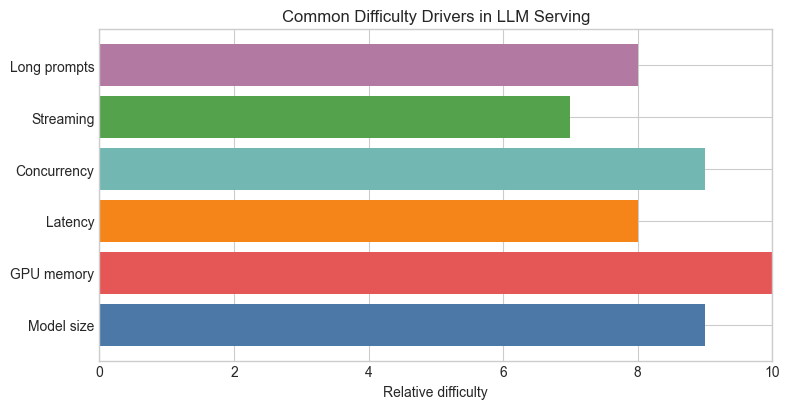

In [6]:
challenge_scores = pd.DataFrame(
    {
        "Challenge": [
            "Model size",
            "GPU memory",
            "Latency",
            "Concurrency",
            "Streaming",
            "Long prompts",
        ],
        "Relative difficulty": [9, 10, 8, 9, 7, 8],
    }
)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(
    challenge_scores["Challenge"],
    challenge_scores["Relative difficulty"],
    color=["#4c78a8", "#e45756", "#f58518", "#72b7b2", "#54a24b", "#b279a2"],
)
ax.set_title("Common Difficulty Drivers in LLM Serving")
ax.set_xlabel("Relative difficulty")
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()


## Token Generation Pipeline

A model response is generated through a loop:

```text
Prompt -> Tokenization -> Forward Pass -> Next Token -> Append Token -> Repeat
```

This loop is the reason serving systems care so much about efficient decoding.


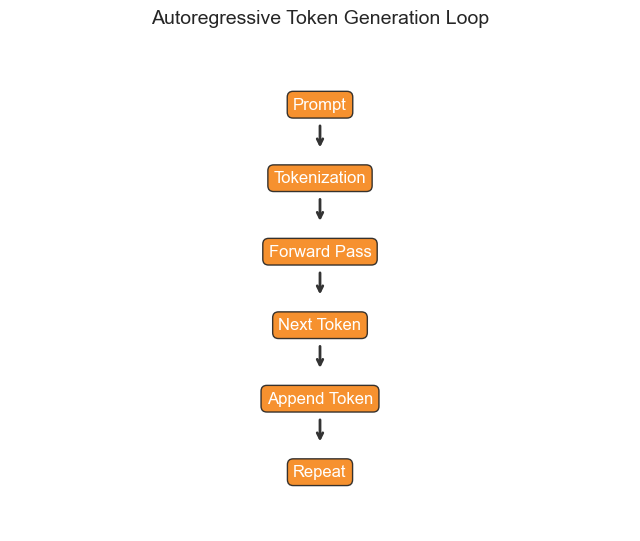

In [7]:
generation_steps = [
    "Prompt",
    "Tokenization",
    "Forward Pass",
    "Next Token",
    "Append Token",
    "Repeat",
]
draw_vertical_pipeline(generation_steps, "Autoregressive Token Generation Loop", "#f58518")


In [8]:
toy_vocabulary = ["<eos>", "LLM", "serving", "uses", "KV", "cache", "for", "speed"]
toy_probabilities = np.array([0.02, 0.08, 0.12, 0.15, 0.2, 0.18, 0.1, 0.15])
toy_probabilities = toy_probabilities / toy_probabilities.sum()

generated_tokens = []
for step in range(6):
    next_token = rng.choice(toy_vocabulary, p=toy_probabilities)
    generated_tokens.append(next_token)
    if next_token == "<eos>":
        break

" ".join(token for token in generated_tokens if token != "<eos>")


'for KV speed cache LLM speed'

## KV Cache

KV cache is one of the most important ideas in LLM inference.

Transformer attention uses **queries**, **keys**, and **values**. During generation, old tokens stay in the context. Without a cache, the model repeatedly recomputes key and value states for tokens it has already processed.

With KV cache, the system stores previous keys and values and only computes new states for the newest token.


In [9]:
kv_table = pd.DataFrame(
    [
        {
            "Approach": "Without KV cache",
            "What happens": "Recompute attention states for the full sequence every step",
            "Effect": "More repeated computation as context grows",
        },
        {
            "Approach": "With KV cache",
            "What happens": "Reuse previous key/value states and append new ones",
            "Effect": "Much faster decoding, with extra memory usage",
        },
    ]
)

kv_table


,Approach,What happens,Effect
0,Without KV cache,Recompute attention states for the full sequen...,More repeated computation as context grows
1,With KV cache,Reuse previous key/value states and append new...,"Much faster decoding, with extra memory usage"


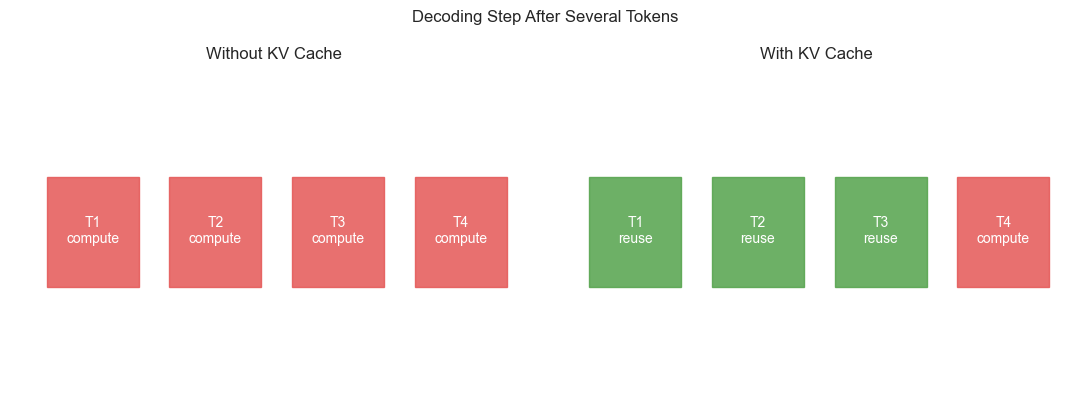

In [10]:
def draw_kv_cache_diagram():
    """Visualize repeated computation versus KV cache reuse."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    tokens = ["T1", "T2", "T3", "T4"]

    for ax, title, cached in zip(
        axes,
        ["Without KV Cache", "With KV Cache"],
        [False, True],
    ):
        for i, token in enumerate(tokens):
            color = "#e45756" if not cached or i == len(tokens) - 1 else "#54a24b"
            ax.add_patch(
                plt.Rectangle((i, 0.5), 0.75, 0.55, color=color, alpha=0.85)
            )
            label = "compute" if color == "#e45756" else "reuse"
            ax.text(i + 0.375, 0.78, f"{token}\n{label}", ha="center", va="center", color="white")

        ax.set_title(title)
        ax.set_xlim(-0.3, len(tokens))
        ax.set_ylim(0, 1.6)
        ax.axis("off")

    plt.suptitle("Decoding Step After Several Tokens")
    plt.tight_layout()
    plt.show()


draw_kv_cache_diagram()


## Toy NumPy KV Cache Example

This is not a full transformer implementation. It is a small simulation of the serving idea:

- Without cache: recompute key/value projections for the whole sequence.
- With cache: compute projections for only the new token and append them.


In [11]:
hidden_size = 8
sequence_length = 6

token_states = rng.normal(size=(sequence_length, hidden_size))
key_projection = rng.normal(size=(hidden_size, hidden_size))
value_projection = rng.normal(size=(hidden_size, hidden_size))


def project_keys_values(states):
    """Project hidden states into toy key and value states."""
    keys = states @ key_projection
    values = states @ value_projection
    return keys, values


def decode_without_cache(states):
    """Recompute all previous key/value states at each decoding step."""
    total_projected_tokens = 0
    for step in range(1, len(states) + 1):
        project_keys_values(states[:step])
        total_projected_tokens += step
    return total_projected_tokens


def decode_with_cache(states):
    """Compute key/value states once per token and append to cache."""
    cached_keys = []
    cached_values = []
    total_projected_tokens = 0

    for step in range(len(states)):
        new_key, new_value = project_keys_values(states[step : step + 1])
        cached_keys.append(new_key)
        cached_values.append(new_value)
        total_projected_tokens += 1

    return np.vstack(cached_keys), np.vstack(cached_values), total_projected_tokens


no_cache_work = decode_without_cache(token_states)
cached_keys, cached_values, cache_work = decode_with_cache(token_states)

pd.DataFrame(
    [
        {"Mode": "Without KV cache", "Projected token states": no_cache_work},
        {"Mode": "With KV cache", "Projected token states": cache_work},
    ]
)


,Mode,Projected token states
0,Without KV cache,21
1,With KV cache,6


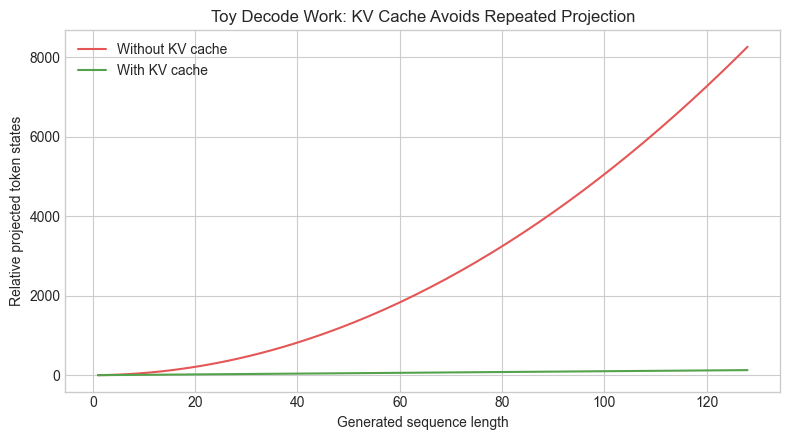

In [12]:
lengths = np.arange(1, 129)
work_without_cache = lengths * (lengths + 1) / 2
work_with_cache = lengths

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lengths, work_without_cache, label="Without KV cache", color="#e45756")
ax.plot(lengths, work_with_cache, label="With KV cache", color="#54a24b")
ax.set_title("Toy Decode Work: KV Cache Avoids Repeated Projection")
ax.set_xlabel("Generated sequence length")
ax.set_ylabel("Relative projected token states")
ax.legend()
plt.tight_layout()
plt.show()


## Continuous Batching

Traditional batching waits for a group of requests, runs them together, and finishes the batch together. This works well when every request has the same length. LLM requests rarely do.

**Continuous batching** lets the server add new requests into the running decode loop as older requests finish. This keeps the GPU busier and reduces wasted capacity.

This is one reason systems such as **vLLM** can be much faster than simple request-at-a-time serving.


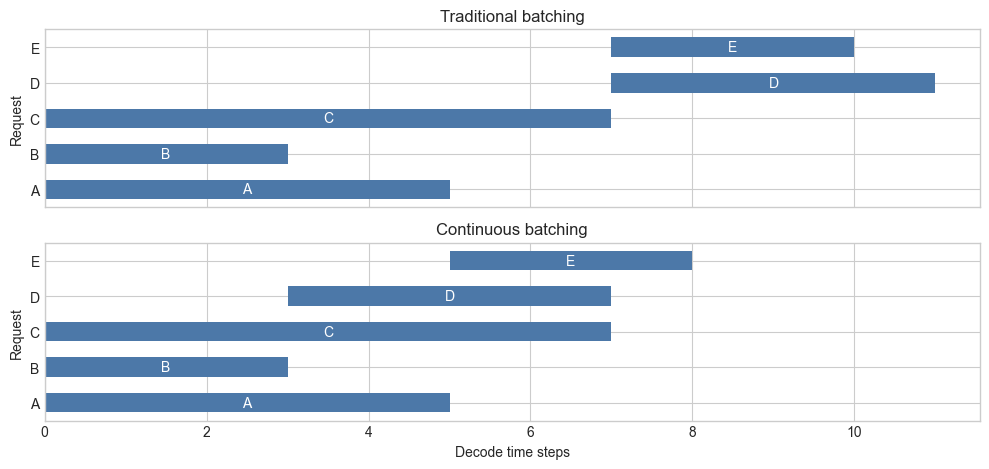

In [13]:
def draw_batching_timeline():
    """Compare traditional and continuous batching timelines."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True)
    requests = [
        ("A", 0, 5),
        ("B", 0, 3),
        ("C", 0, 7),
        ("D", 3, 4),
        ("E", 5, 3),
    ]

    for ax, title, continuous in zip(
        axes,
        ["Traditional batching", "Continuous batching"],
        [False, True],
    ):
        for row, (name, arrival, duration) in enumerate(requests):
            start = arrival if continuous else 0 if name in ["A", "B", "C"] else 7
            ax.barh(row, duration, left=start, height=0.55, color="#4c78a8")
            ax.text(start + duration / 2, row, name, ha="center", va="center", color="white")

        ax.set_yticks(range(len(requests)))
        ax.set_yticklabels([request[0] for request in requests])
        ax.set_title(title)
        ax.set_ylabel("Request")

    axes[-1].set_xlabel("Decode time steps")
    plt.tight_layout()
    plt.show()


draw_batching_timeline()


In [14]:
batching_table = pd.DataFrame(
    [
        {
            "Feature": "Traditional batching",
            "Behavior": "Batch starts and ends as a group",
            "Problem": "Short requests wait for long requests",
        },
        {
            "Feature": "Continuous batching",
            "Behavior": "Requests enter and leave dynamically",
            "Problem": "More complex scheduling and cache management",
        },
    ]
)

batching_table


,Feature,Behavior,Problem
0,Traditional batching,Batch starts and ends as a group,Short requests wait for long requests
1,Continuous batching,Requests enter and leave dynamically,More complex scheduling and cache management


## Streaming Responses

Chat products stream tokens because users should not have to wait for the full answer before seeing progress.

Streaming improves perceived latency:

- **Time to first token** becomes more important than total generation time.
- The client can render partial output.
- Long responses feel more responsive.


In [15]:
def toy_stream(tokens: Iterable[str]):
    """Yield tokens one at a time as a toy streaming response."""
    for token in tokens:
        yield token


streamed_tokens = ["Serving", " ", "LLMs", " ", "means", " ", "generating", " ", "tokens", "."]
partial_response = ""

for chunk in toy_stream(streamed_tokens):
    partial_response += chunk
    print(partial_response)


Serving
Serving 
Serving LLMs
Serving LLMs 
Serving LLMs means
Serving LLMs means 
Serving LLMs means generating
Serving LLMs means generating 
Serving LLMs means generating tokens
Serving LLMs means generating tokens.


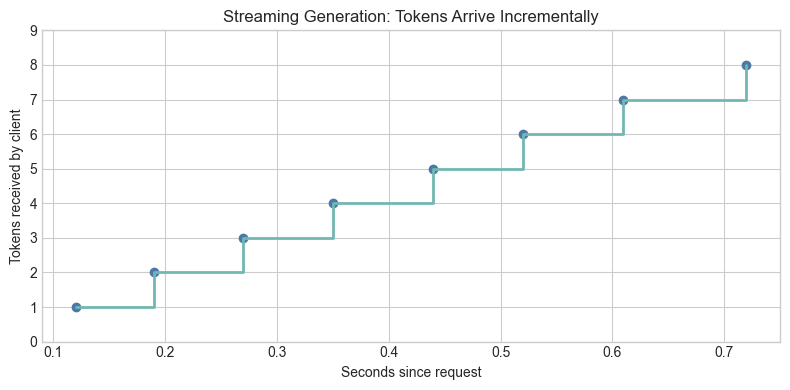

In [16]:
token_times = np.array([0.12, 0.19, 0.27, 0.35, 0.44, 0.52, 0.61, 0.72])
token_numbers = np.arange(1, len(token_times) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.step(token_times, token_numbers, where="post", color="#72b7b2", linewidth=2)
ax.scatter(token_times, token_numbers, color="#4c78a8")
ax.set_title("Streaming Generation: Tokens Arrive Incrementally")
ax.set_xlabel("Seconds since request")
ax.set_ylabel("Tokens received by client")
ax.set_ylim(0, len(token_times) + 1)
plt.tight_layout()
plt.show()


## OpenAI API Style Serving

Many production systems expose LLMs through an HTTP JSON API.

A typical request flow:

```text
Prompt -> HTTP Request -> Tokenizer -> LLM -> Generated Tokens -> JSON Response
```

Even when the backend uses custom GPU kernels, paged attention, queues, and distributed workers, the client usually sees a clean JSON interface.


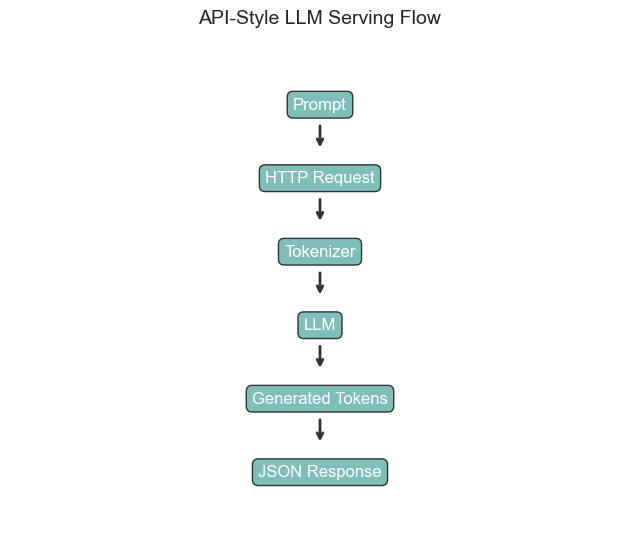

In [17]:
api_steps = [
    "Prompt",
    "HTTP Request",
    "Tokenizer",
    "LLM",
    "Generated Tokens",
    "JSON Response",
]
draw_vertical_pipeline(api_steps, "API-Style LLM Serving Flow", "#72b7b2")


In [18]:
sample_response = {
    "id": "chatcmpl_demo_001",
    "object": "chat.completion",
    "model": "portfolio-llm-demo",
    "choices": [
        {
            "index": 0,
            "message": {
                "role": "assistant",
                "content": "LLM serving turns a trained model into a scalable API.",
            },
            "finish_reason": "stop",
        }
    ],
    "usage": {
        "prompt_tokens": 12,
        "completion_tokens": 13,
        "total_tokens": 25,
    },
}

print(json.dumps(sample_response, indent=2))


{
  "id": "chatcmpl_demo_001",
  "object": "chat.completion",
  "model": "portfolio-llm-demo",
  "choices": [
    {
      "index": 0,
      "message": {
        "role": "assistant",
        "content": "LLM serving turns a trained model into a scalable API."
      },
      "finish_reason": "stop"
    }
  ],
  "usage": {
    "prompt_tokens": 12,
    "completion_tokens": 13,
    "total_tokens": 25
  }
}


## FastAPI Example

A real production service would load a model through a serving engine. For this learning notebook, we will build a minimal API shape without loading a heavy model.

The endpoint accepts a prompt and returns a dummy generated response. The point is to understand the serving interface, not to run GPU inference.


In [19]:
try:
    from fastapi import FastAPI
    from pydantic import BaseModel
except ImportError:
    FastAPI = None
    BaseModel = object


if FastAPI is not None:
    try:
        class GenerateRequest(BaseModel):
            prompt: str
            max_tokens: int = 32

        app = FastAPI(title="Toy LLM Serving API")

        @app.get("/health")
        def health():
            return {"status": "ok"}

        @app.post("/generate")
        def generate_endpoint(request: GenerateRequest):
            return {
                "text": f"Dummy completion for: {request.prompt}",
                "max_tokens": request.max_tokens,
            }

        fastapi_status = "FastAPI app object created. Run with: uvicorn module_name:app"
    except Exception as error:
        app = None
        fastapi_status = f"FastAPI is available, but app creation failed in this environment: {error}"
else:
    app = None
    fastapi_status = "FastAPI is not installed, so this cell shows the API design only."

fastapi_status


/Users/mihrinur/.pyenv/versions/3.11.6/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fastapi/applications.py:18: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  from fastapi.exception_handlers import (
/Users/mihrinur/.pyenv/versions/3.11.6/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fastapi/applications.py:30: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  from fastapi.openapi.utils import get_openapi


"FastAPI is available, but app creation failed in this environment: Router.__init__() got an unexpected keyword argument 'on_startup'"

In [20]:
endpoint_table = pd.DataFrame(
    [
        {
            "Endpoint": "GET /health",
            "Purpose": "Health check for load balancers and orchestration",
            "Returns": '{"status": "ok"}',
        },
        {
            "Endpoint": "POST /generate",
            "Purpose": "Accept a prompt and return generated text",
            "Returns": "Generated text plus request metadata",
        },
    ]
)

endpoint_table


,Endpoint,Purpose,Returns
0,GET /health,Health check for load balancers and orchestration,"{""status"": ""ok""}"
1,POST /generate,Accept a prompt and return generated text,Generated text plus request metadata


## Modern LLM Serving Frameworks

Production teams rarely build everything from scratch. They usually choose a serving engine or API gateway that matches their model, hardware, latency target, and operational constraints.


In [21]:
serving_frameworks = pd.DataFrame(
    [
        {
            "Framework": "vLLM",
            "Practical role": "High-throughput open-source LLM serving engine",
            "Useful when": "You need efficient batching and KV cache management",
        },
        {
            "Framework": "Text Generation Inference (TGI)",
            "Practical role": "Hugging Face serving stack for text generation models",
            "Useful when": "You want production-focused model serving containers",
        },
        {
            "Framework": "Ollama",
            "Practical role": "Local model runner with a simple developer experience",
            "Useful when": "You want local inference and easy model management",
        },
        {
            "Framework": "llama.cpp",
            "Practical role": "Efficient local inference runtime, often with GGUF models",
            "Useful when": "You need CPU or consumer-device inference",
        },
        {
            "Framework": "OpenAI API",
            "Practical role": "Managed hosted inference API",
            "Useful when": "You want model access without operating serving infrastructure",
        },
        {
            "Framework": "LiteLLM",
            "Practical role": "Gateway and compatibility layer across model providers",
            "Useful when": "You need routing, fallbacks, budgets, or provider abstraction",
        },
    ]
)

serving_frameworks


,Framework,Practical role,Useful when
0,vLLM,High-throughput open-source LLM serving engine,You need efficient batching and KV cache manag...
1,Text Generation Inference (TGI),Hugging Face serving stack for text generation...,You want production-focused model serving cont...
2,Ollama,Local model runner with a simple developer exp...,You want local inference and easy model manage...
3,llama.cpp,"Efficient local inference runtime, often with ...",You need CPU or consumer-device inference
4,OpenAI API,Managed hosted inference API,You want model access without operating servin...
5,LiteLLM,Gateway and compatibility layer across model p...,"You need routing, fallbacks, budgets, or provi..."


## Deployment Workflow

A practical deployment often looks like this:

```text
Model -> Quantization -> Serving Engine -> API -> Load Balancer -> Users
```

Each stage changes the operational profile of the system.


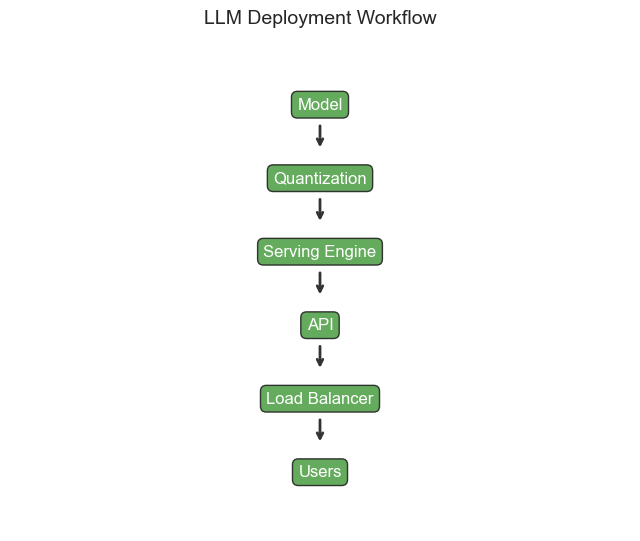

In [22]:
deployment_steps = [
    "Model",
    "Quantization",
    "Serving Engine",
    "API",
    "Load Balancer",
    "Users",
]
draw_vertical_pipeline(deployment_steps, "LLM Deployment Workflow", "#54a24b")


## Mini Project: Toy LLM Server Simulator

Now we will build a small simulator for the request lifecycle.

Functions:

- `receive_request()`
- `tokenize()`
- `generate()`
- `stream()`
- `return_response()`


In [23]:
@dataclass
class ToyRequest:
    request_id: str
    prompt: str
    max_tokens: int = 16


def receive_request(prompt: str, max_tokens: int = 16) -> ToyRequest:
    """Create a normalized request object."""
    return ToyRequest(
        request_id=f"req_{rng.integers(1000, 9999)}",
        prompt=prompt.strip(),
        max_tokens=max_tokens,
    )


def tokenize(text: str) -> List[str]:
    """Tokenize text with a simple whitespace tokenizer."""
    return text.split()


def generate(tokens: List[str], max_tokens: int = 16) -> List[str]:
    """Generate a deterministic toy completion."""
    base = ["This", "request", "was", "served", "by", "a", "toy", "LLM", "API", "."]
    return base[:max_tokens]


def stream(tokens: List[str]) -> Iterable[str]:
    """Yield generated tokens as response chunks."""
    for token in tokens:
        yield token


def return_response(request: ToyRequest, generated_tokens: List[str]) -> Dict[str, object]:
    """Create an API-style response dictionary."""
    return {
        "request_id": request.request_id,
        "text": " ".join(generated_tokens),
        "usage": {
            "prompt_tokens": len(tokenize(request.prompt)),
            "completion_tokens": len(generated_tokens),
            "total_tokens": len(tokenize(request.prompt)) + len(generated_tokens),
        },
    }


In [24]:
request = receive_request("Explain LLM serving in one sentence.", max_tokens=10)
prompt_tokens = tokenize(request.prompt)
generated = generate(prompt_tokens, request.max_tokens)
response = return_response(request, generated)

print("Streaming chunks:")
for chunk in stream(generated):
    print(chunk)

print("\nFinal response:")
print(json.dumps(response, indent=2))


Streaming chunks:
This
request
was
served
by
a
toy
LLM
API
.

Final response:
{
  "request_id": "req_4019",
  "text": "This request was served by a toy LLM API .",
  "usage": {
    "prompt_tokens": 6,
    "completion_tokens": 10,
    "total_tokens": 16
  }
}


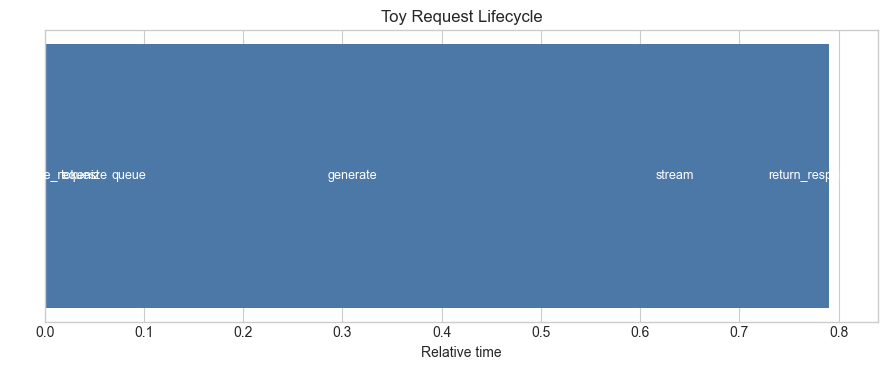

In [25]:
lifecycle_events = [
    ("receive_request", 0.02),
    ("tokenize", 0.04),
    ("queue", 0.05),
    ("generate", 0.40),
    ("stream", 0.25),
    ("return_response", 0.03),
]

fig, ax = plt.subplots(figsize=(9, 3.8))
start = 0
for event, duration in lifecycle_events:
    ax.barh(0, duration, left=start, height=0.45, color="#4c78a8")
    ax.text(start + duration / 2, 0, event, ha="center", va="center", color="white", fontsize=9)
    start += duration

ax.set_title("Toy Request Lifecycle")
ax.set_xlabel("Relative time")
ax.set_yticks([])
ax.set_xlim(0, start + 0.05)
plt.tight_layout()
plt.show()


## Common Production Problems

Production LLM systems fail in predictable ways:

- **Latency spikes** when queues grow or prompts are long.
- **GPU memory pressure** increases with model size, batch size, and KV cache.
- **Timeouts** happen when generation takes longer than client or gateway limits.
- **OOM errors** occur when the server admits too much work.
- **Cold starts** happen when loading large weights or scaling new replicas.
- **Long prompts** consume context, memory, and prefill time.


In [26]:
problems_table = pd.DataFrame(
    [
        {
            "Problem": "Latency",
            "Symptom": "Slow first token or slow full response",
            "Typical mitigation": "Batching, optimized kernels, shorter prompts",
        },
        {
            "Problem": "GPU memory",
            "Symptom": "OOM or low concurrency",
            "Typical mitigation": "Quantization, smaller batch limits, KV cache planning",
        },
        {
            "Problem": "Timeouts",
            "Symptom": "Requests fail before generation completes",
            "Typical mitigation": "Streaming, timeout tuning, max token limits",
        },
        {
            "Problem": "Cold starts",
            "Symptom": "First request after scaling is slow",
            "Typical mitigation": "Warm pools, preloading, autoscaling buffers",
        },
        {
            "Problem": "Long prompts",
            "Symptom": "High prefill latency and cache memory",
            "Typical mitigation": "Prompt limits, truncation, retrieval compression",
        },
    ]
)

problems_table


,Problem,Symptom,Typical mitigation
0,Latency,Slow first token or slow full response,"Batching, optimized kernels, shorter prompts"
1,GPU memory,OOM or low concurrency,"Quantization, smaller batch limits, KV cache p..."
2,Timeouts,Requests fail before generation completes,"Streaming, timeout tuning, max token limits"
3,Cold starts,First request after scaling is slow,"Warm pools, preloading, autoscaling buffers"
4,Long prompts,High prefill latency and cache memory,"Prompt limits, truncation, retrieval compression"


## Best Practices

Strong LLM serving systems usually include:

- **Batching** to improve accelerator utilization.
- **Streaming** to reduce perceived latency.
- **Caching** for repeated prefixes, retrieval results, or generated outputs when appropriate.
- **Prompt limits** to protect latency and memory.
- **Monitoring** for latency, throughput, token counts, errors, queue depth, and GPU memory.
- **Fallbacks** for overloaded providers or degraded backends.


In [27]:
best_practices = pd.DataFrame(
    [
        {"Practice": "Batching", "Metric improved": "Throughput", "Watch out for": "Queue latency"},
        {"Practice": "Streaming", "Metric improved": "Perceived latency", "Watch out for": "Client disconnects"},
        {"Practice": "Caching", "Metric improved": "Cost and latency", "Watch out for": "Stale or unsafe reuse"},
        {"Practice": "Prompt limits", "Metric improved": "Reliability", "Watch out for": "User experience"},
        {"Practice": "Monitoring", "Metric improved": "Operations", "Watch out for": "Missing token-level metrics"},
    ]
)

best_practices


,Practice,Metric improved,Watch out for
0,Batching,Throughput,Queue latency
1,Streaming,Perceived latency,Client disconnects
2,Caching,Cost and latency,Stale or unsafe reuse
3,Prompt limits,Reliability,User experience
4,Monitoring,Operations,Missing token-level metrics


## Final Summary

LLM serving turns a trained and aligned model into a usable production API.

The core pipeline is:

```text
User -> API -> Tokenizer -> LLM -> Decoder -> Response
```

Modern serving systems are built around the realities of autoregressive generation: token-by-token decoding, KV cache, streaming, batching, concurrency, and memory limits.

KV cache avoids repeated attention-state computation. Continuous batching keeps accelerators busy as requests arrive and finish dynamically. Streaming sends partial tokens to improve user experience. Production APIs wrap all of this behind a stable interface.


## Next Notebook

➡️ **Next: Evaluating Large Language Models**

After deployment, the next challenge is measuring model quality.

Evaluation helps answer whether the served model is accurate, safe, useful, consistent, and reliable under realistic user traffic.
